In [1]:
!pip install imblearn

In [1]:
# =============================
# IMPORTS
# =============================
import os
import time
import psutil

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import BorderlineSMOTE

In [2]:
# =============================
# DEVICE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [3]:
# =============================
# DATA PATH
# =============================
DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

In [4]:
# =============================
# CLEANING
# =============================
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))

In [5]:
# =============================
# DATASET
# =============================
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
# =============================
# SIMPLE GNN LAYER
# =============================
class SimpleGNNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        num_features = x.shape[1]
        A = torch.ones((num_features, num_features), device=x.device) / num_features
        x = torch.matmul(x, A)
        return torch.relu(self.linear(x))

In [7]:
# =============================
# MODEL: CNN + LSTM + GNN
# =============================
class RobustParallelModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cnn_fc = nn.Linear(32, hidden_dim)

        # LSTM
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # GNN
        self.gnn1 = SimpleGNNLayer(input_dim, hidden_dim)
        self.gnn2 = SimpleGNNLayer(hidden_dim, hidden_dim)

        # Fusion
        self.fusion_weights = nn.Parameter(torch.ones(3))

        # Classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN
        cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM
        lstm_out, _ = self.lstm(x.unsqueeze(1))
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # GNN
        gnn_feat = self.gnn1(x)
        gnn_feat = self.gnn2(gnn_feat)

        # Fusion
        weights = torch.softmax(self.fusion_weights, dim=0)

        fused = (
            weights[0] * cnn_feat +
            weights[1] * lstm_feat +
            weights[2] * gnn_feat
        )

        logits = self.classifier(fused)

        # ✅ FINAL SOFTMAX
        return torch.softmax(logits, dim=1)

In [8]:
# =============================
# TRAIN FUNCTION
# =============================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        # ✅ convert to log for NLLLoss
        log_outputs = torch.log(outputs + 1e-9)

        loss = criterion(log_outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [9]:
# =============================
# EVALUATION
# =============================
def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)   # already softmax

            prob = outputs

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs

# Borderline SMOTE

In [12]:
def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # SMOTE
    # =============================
    smote = BorderlineSMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER Sampling"
    )
    plt.show()

    # =============================
    # SCALING (UPDATED)
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


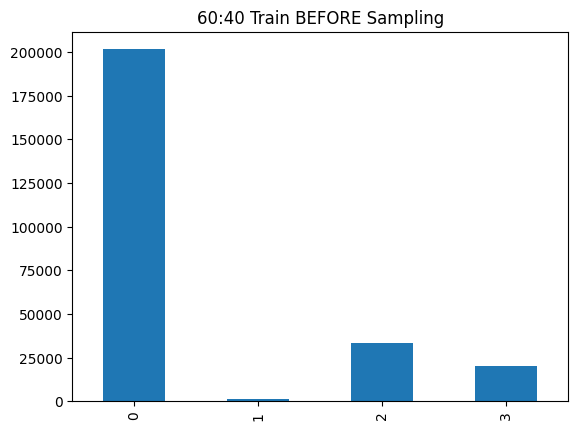

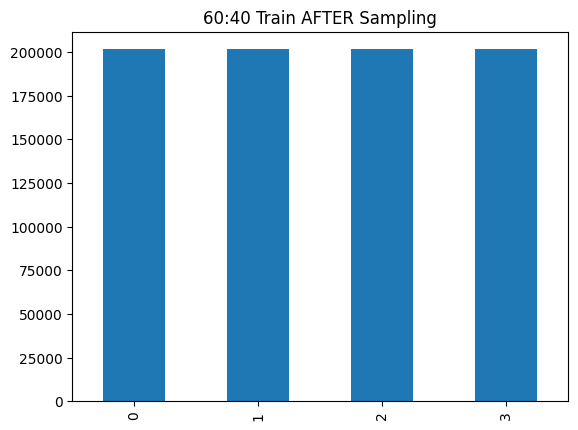

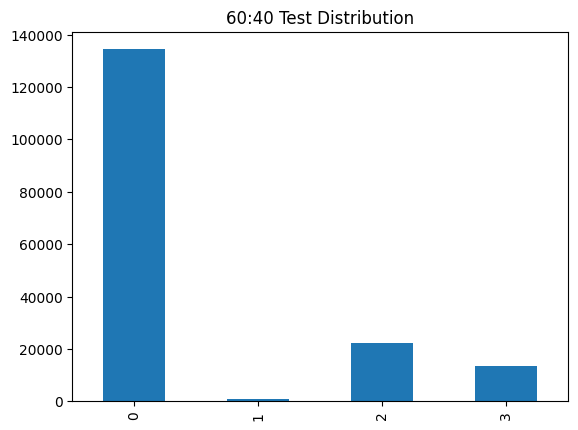

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.0585, TrainAcc=0.9802, TestAcc=0.9818, ROC-AUC=0.9993
Epoch 2: Loss=0.0260, TrainAcc=0.9921, TestAcc=0.9811, ROC-AUC=0.9994
Epoch 3: Loss=0.0233, TrainAcc=0.9928, TestAcc=0.9816, ROC-AUC=0.9995
Epoch 4: Loss=0.0217, TrainAcc=0.9934, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 5: Loss=0.0207, TrainAcc=0.9936, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 6: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 7: Loss=0.0195, TrainAcc=0.9940, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 8: Loss=0.0191, TrainAcc=0.9942, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 9: Loss=0.0185, TrainAcc=0.9944, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 10: Loss=0.0182, TrainAcc=0.9944, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 11: Loss=0.0180, TrainAcc=0.9945, TestAcc=0.9861, ROC-AUC=0.9995
Epoch 12: Loss=0.0176, TrainAcc=0.9946, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 13: Loss=0.0175, TrainAcc=0.9946, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 14: Loss=0.0173, TrainAcc=0.9947, TestAcc=

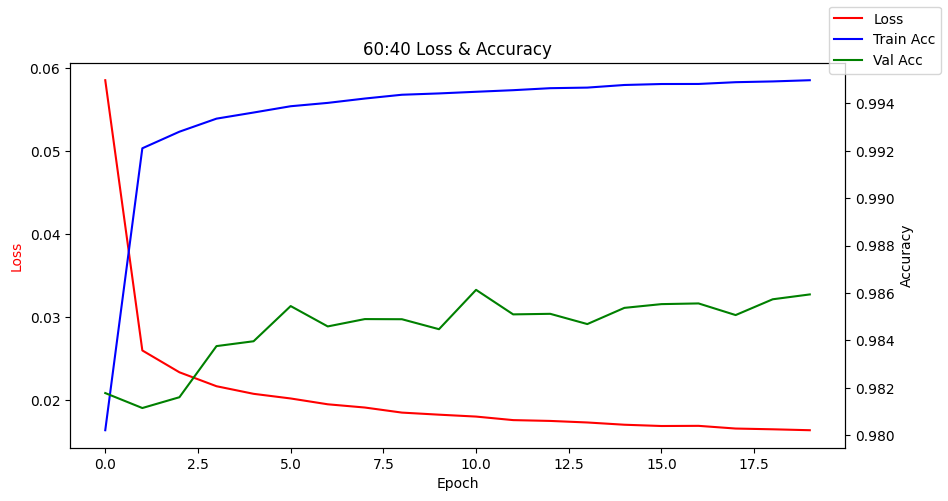

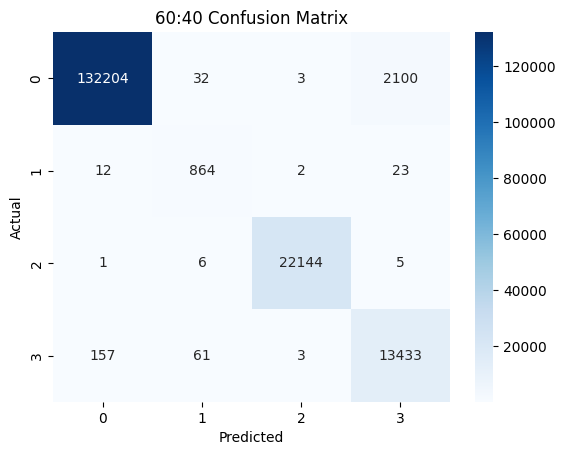

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.90      0.96      0.93       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.98      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.94      0.98      0.96    171050
weighted avg       0.99      0.99      0.99    171050



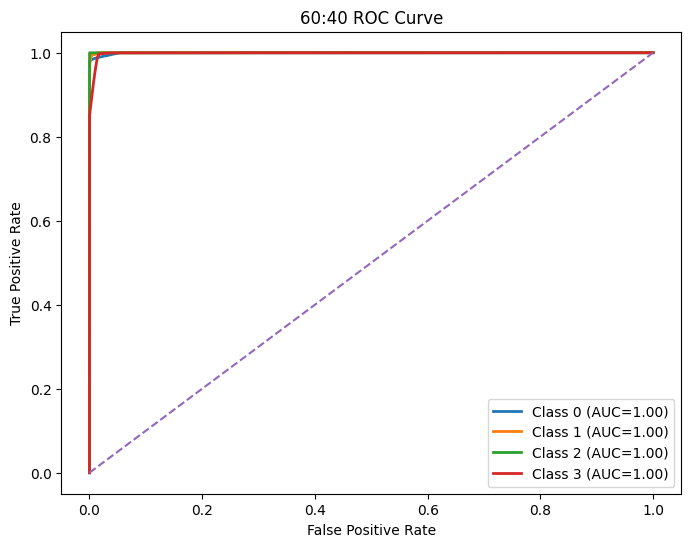

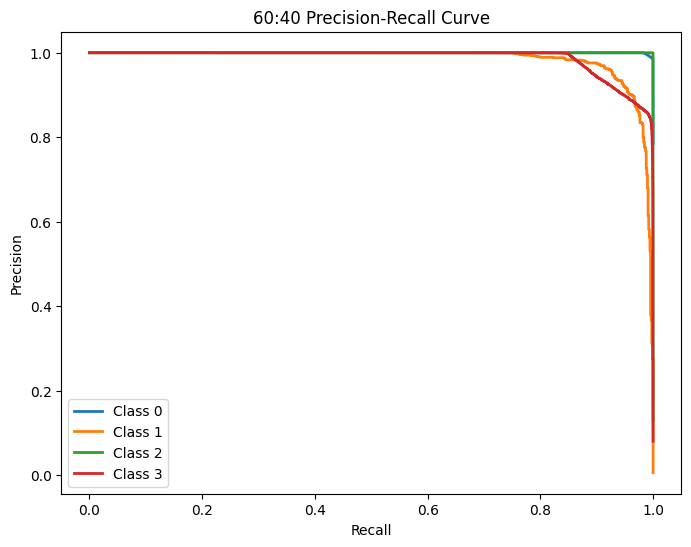


⏱️ Runtime: 1151.76 sec
💾 RAM used: 1026.89 MB

========== 70:30 ==========


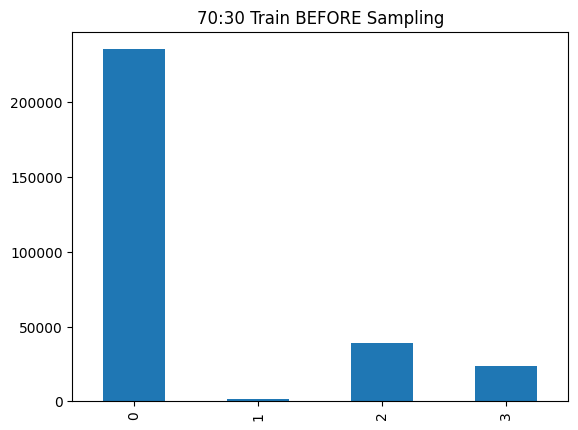

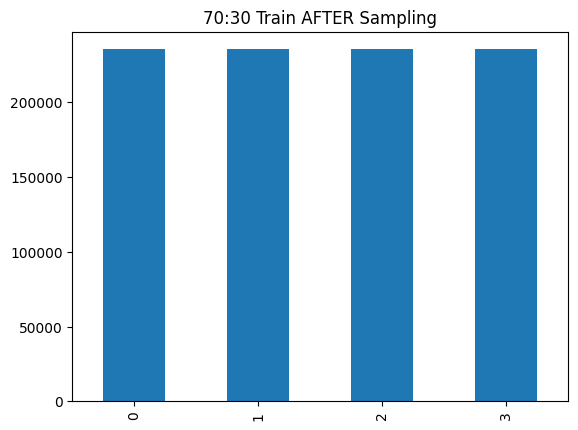

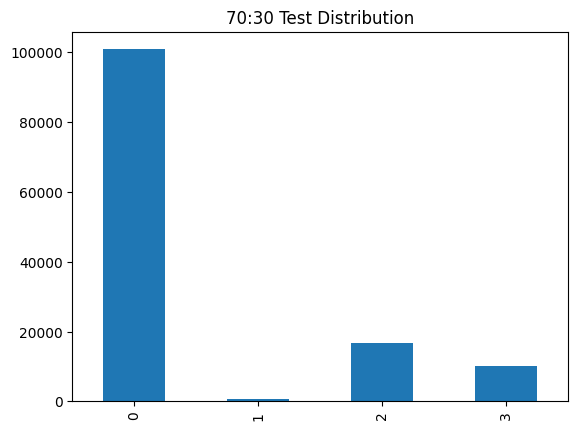

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.0549, TrainAcc=0.9817, TestAcc=0.9747, ROC-AUC=0.9993
Epoch 2: Loss=0.0265, TrainAcc=0.9918, TestAcc=0.9814, ROC-AUC=0.9995
Epoch 3: Loss=0.0239, TrainAcc=0.9926, TestAcc=0.9818, ROC-AUC=0.9995
Epoch 4: Loss=0.0219, TrainAcc=0.9933, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 5: Loss=0.0207, TrainAcc=0.9937, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 6: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 7: Loss=0.0196, TrainAcc=0.9941, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 8: Loss=0.0192, TrainAcc=0.9942, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 9: Loss=0.0185, TrainAcc=0.9944, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 10: Loss=0.0183, TrainAcc=0.9944, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 11: Loss=0.0179, TrainAcc=0.9945, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 12: Loss=0.0177, TrainAcc=0.9946, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 13: Loss=0.0175, TrainAcc=0.9947, TestAcc=0.9853, ROC-AUC=0.9996
Epoch 14: Loss=0.0173, TrainAcc=0.9947, TestAcc=

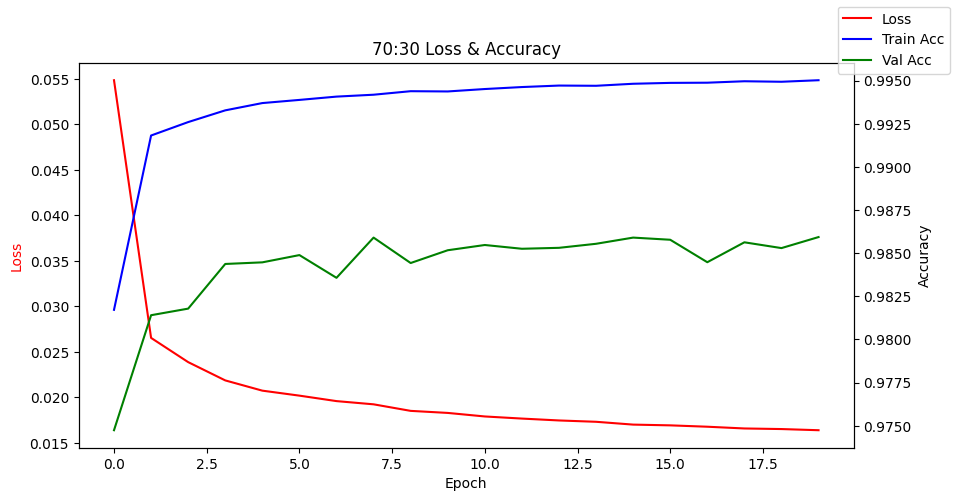

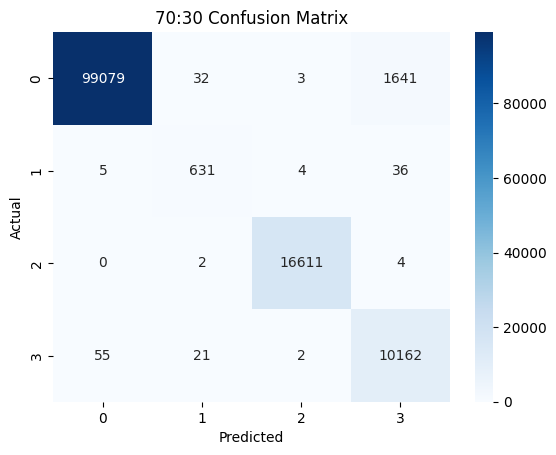

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.92      0.93      0.93       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.98      0.96    128288
weighted avg       0.99      0.99      0.99    128288



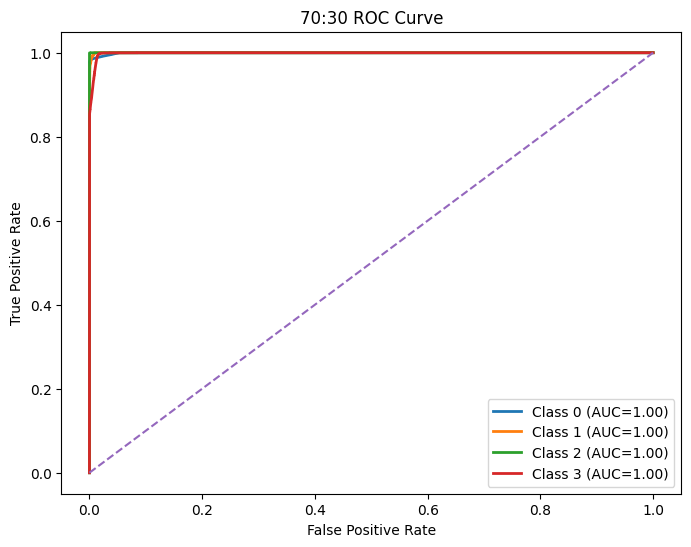

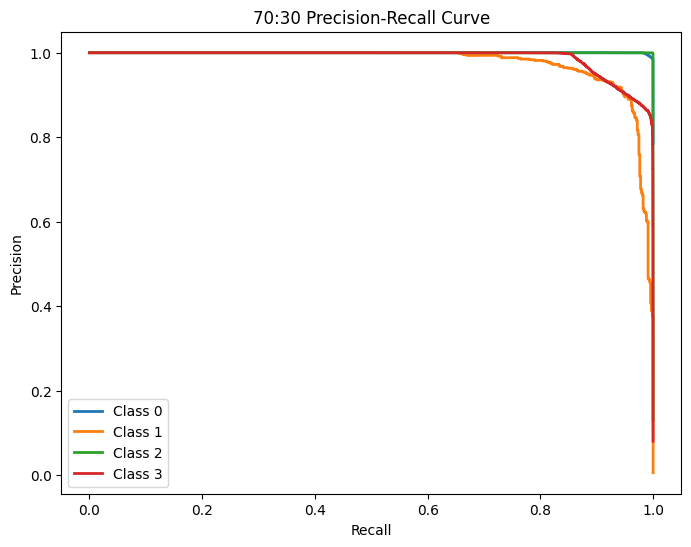


⏱️ Runtime: 1308.37 sec
💾 RAM used: 414.90 MB

========== 80:20 ==========


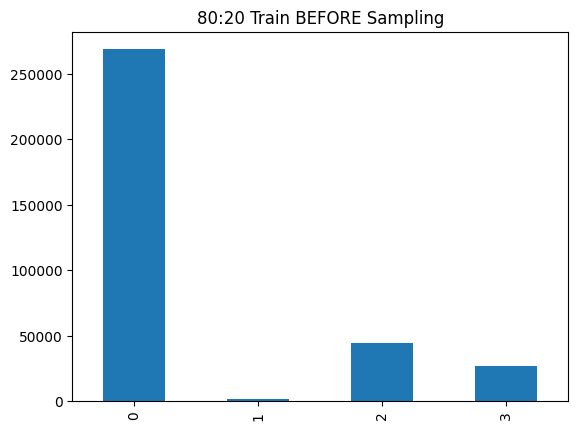

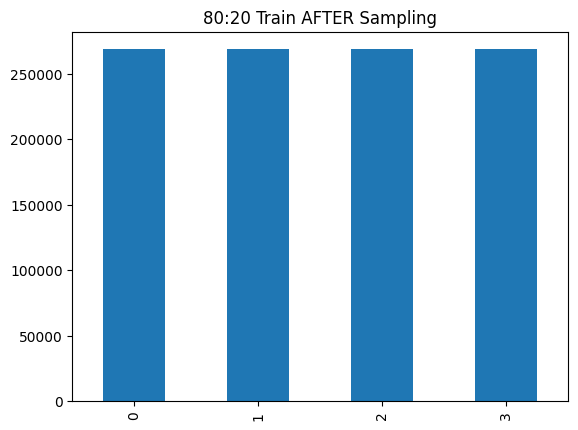

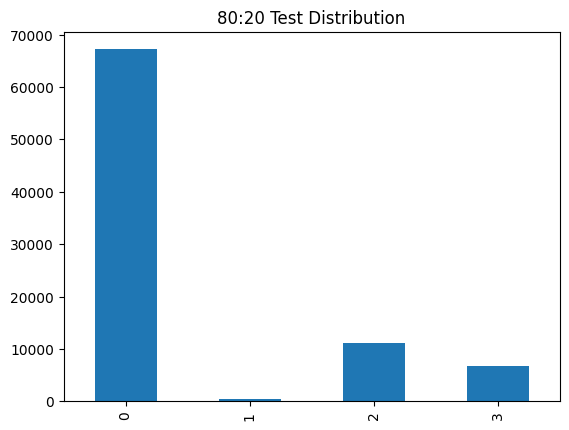

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.0513, TrainAcc=0.9831, TestAcc=0.9800, ROC-AUC=0.9994
Epoch 2: Loss=0.0257, TrainAcc=0.9921, TestAcc=0.9817, ROC-AUC=0.9995
Epoch 3: Loss=0.0228, TrainAcc=0.9930, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 4: Loss=0.0214, TrainAcc=0.9934, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 5: Loss=0.0205, TrainAcc=0.9937, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 6: Loss=0.0199, TrainAcc=0.9940, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 7: Loss=0.0193, TrainAcc=0.9942, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 8: Loss=0.0189, TrainAcc=0.9943, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 9: Loss=0.0186, TrainAcc=0.9944, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 10: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9853, ROC-AUC=0.9996
Epoch 11: Loss=0.0180, TrainAcc=0.9946, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9946, TestAcc=0.9854, ROC-AUC=0.9996
Epoch 13: Loss=0.0175, TrainAcc=0.9947, TestAcc=0.9857, ROC-AUC=0.9996
Epoch 14: Loss=0.0174, TrainAcc=0.9948, TestAcc=

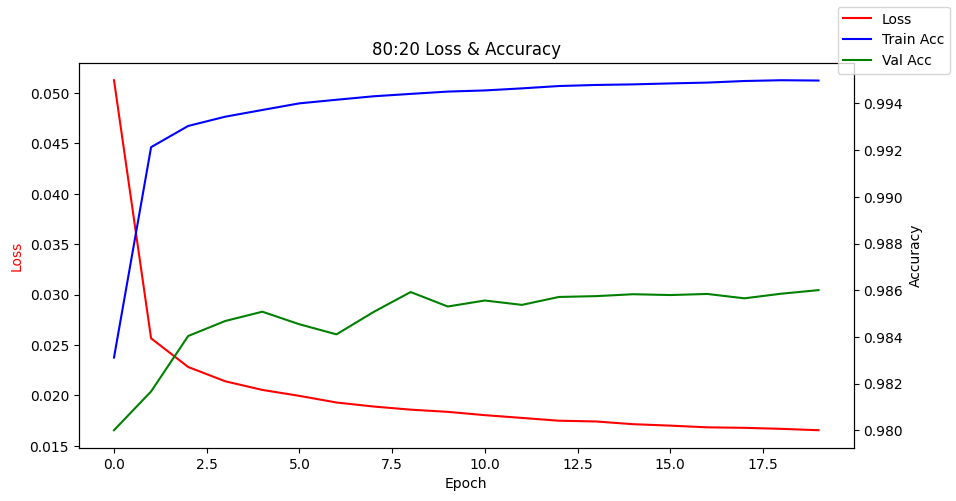

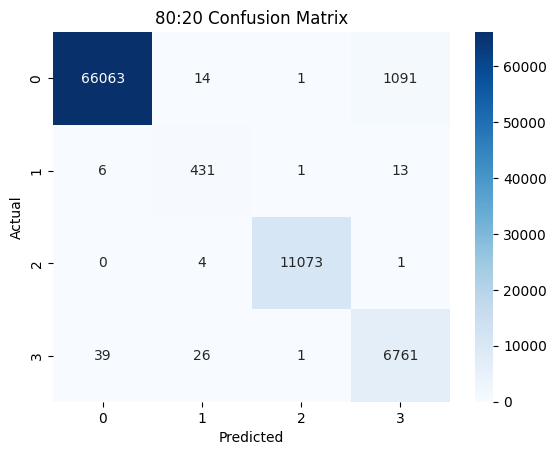

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.91      0.96      0.93       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.98      0.96     85525
weighted avg       0.99      0.99      0.99     85525



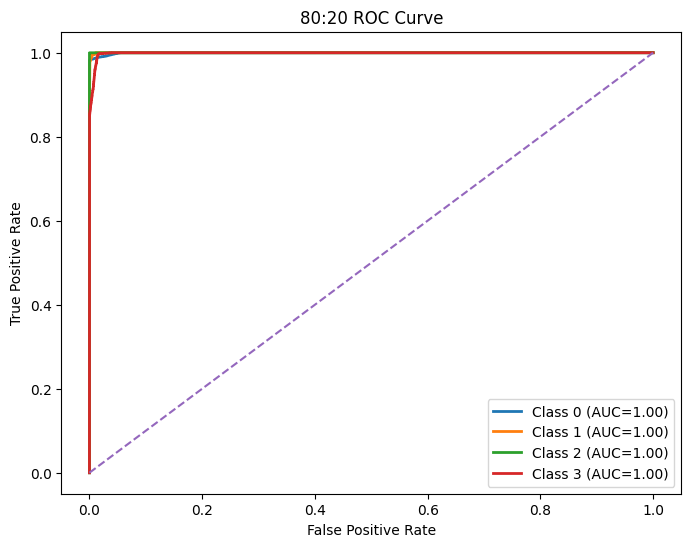

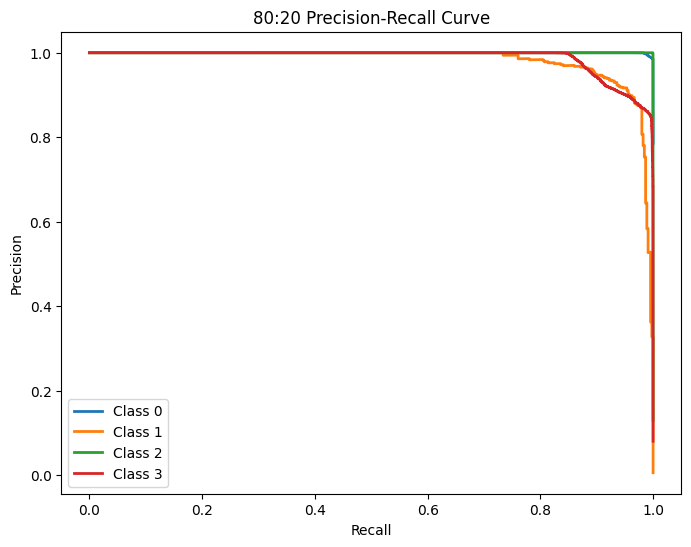


⏱️ Runtime: 1472.60 sec
💾 RAM used: 469.10 MB


In [13]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# SMOTE

In [14]:
def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} (SMOTE) ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # SMOTE (ONLY)
    # =============================
    from imblearn.over_sampling import SMOTE
    smote = SMOTE()

    X_train, y_train = smote.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER SMOTE"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 (SMOTE) ==========


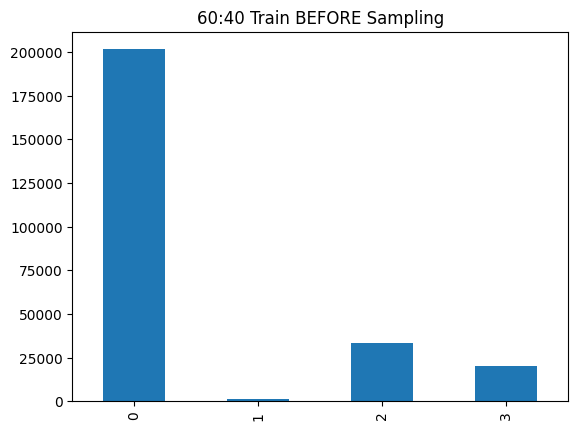

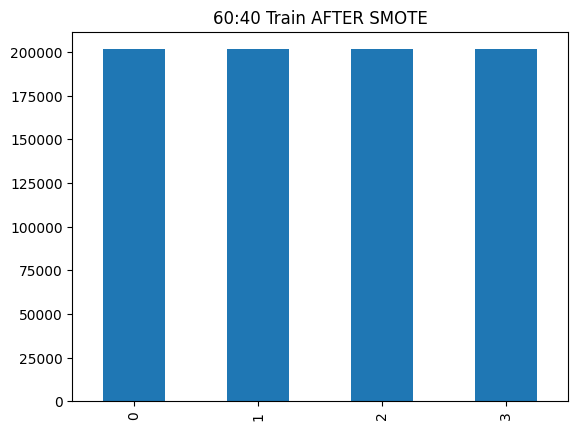

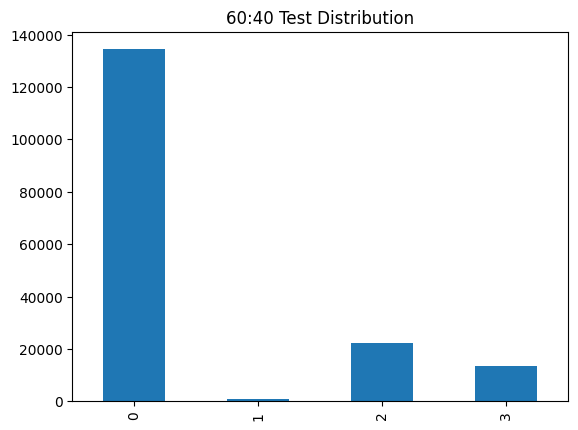

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.0562, TrainAcc=0.9803, TestAcc=0.9810, ROC-AUC=0.9994
Epoch 2: Loss=0.0264, TrainAcc=0.9911, TestAcc=0.9810, ROC-AUC=0.9994
Epoch 3: Loss=0.0234, TrainAcc=0.9922, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 4: Loss=0.0217, TrainAcc=0.9927, TestAcc=0.9826, ROC-AUC=0.9995
Epoch 5: Loss=0.0205, TrainAcc=0.9931, TestAcc=0.9831, ROC-AUC=0.9995
Epoch 6: Loss=0.0195, TrainAcc=0.9935, TestAcc=0.9825, ROC-AUC=0.9995
Epoch 7: Loss=0.0187, TrainAcc=0.9938, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 8: Loss=0.0181, TrainAcc=0.9940, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 9: Loss=0.0176, TrainAcc=0.9941, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 10: Loss=0.0172, TrainAcc=0.9942, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 11: Loss=0.0169, TrainAcc=0.9943, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 12: Loss=0.0166, TrainAcc=0.9944, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 13: Loss=0.0162, TrainAcc=0.9945, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 14: Loss=0.0160, TrainAcc=0.9945, TestAcc=

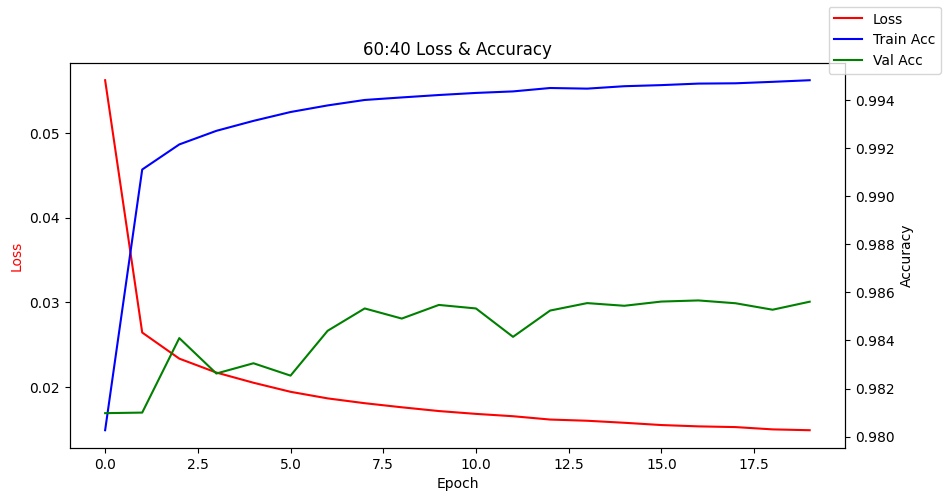

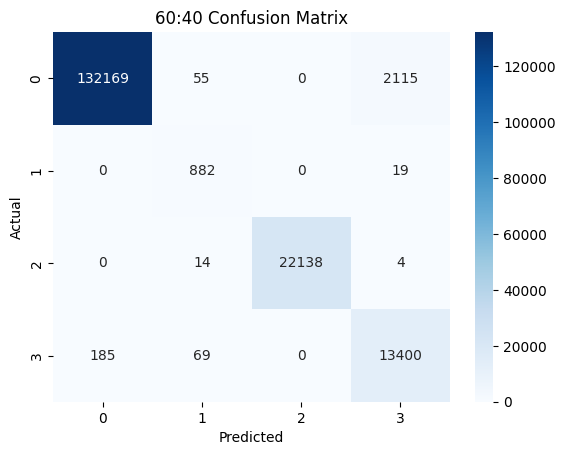

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.86      0.98      0.92       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.98      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.93      0.99      0.96    171050
weighted avg       0.99      0.99      0.99    171050



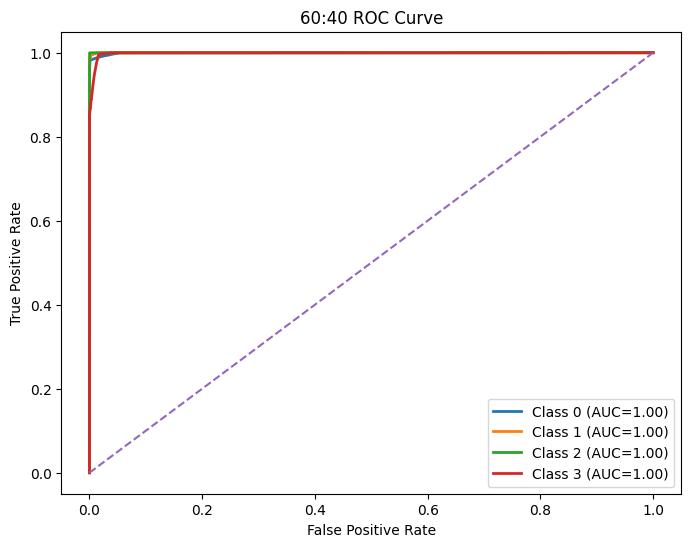

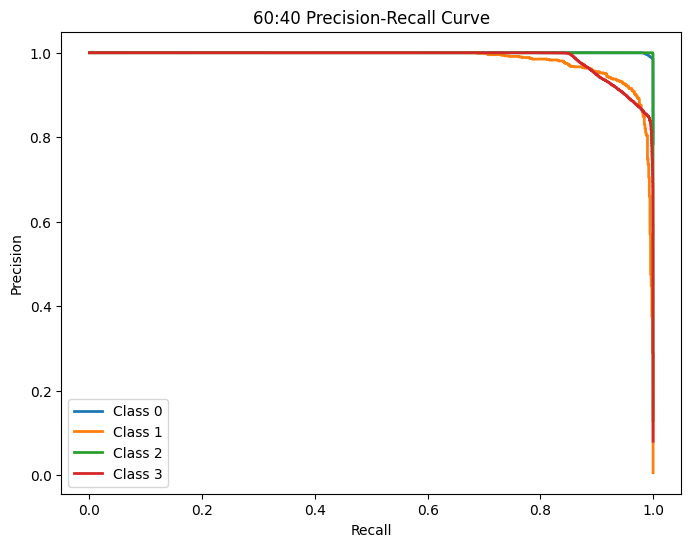


⏱️ Runtime: 1104.66 sec
💾 RAM used: 317.01 MB

========== 70:30 (SMOTE) ==========


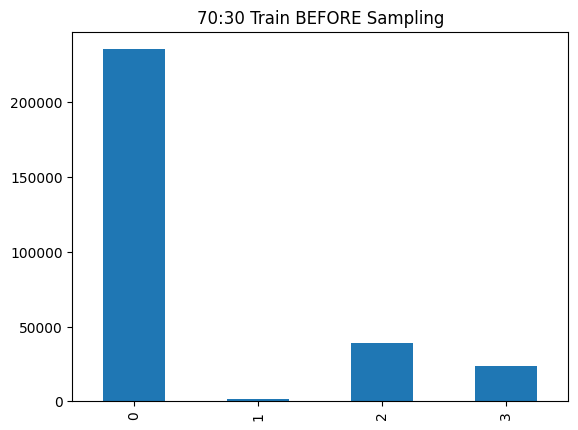

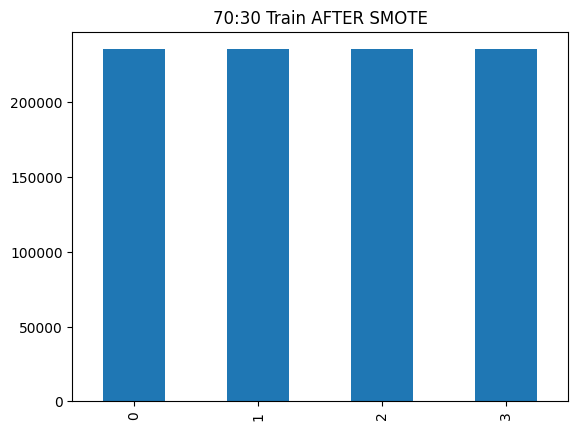

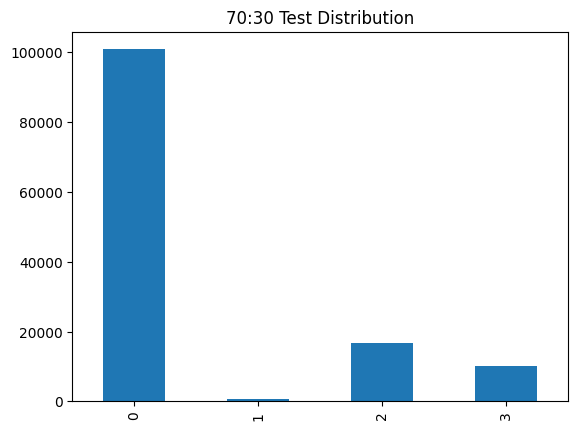

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.0520, TrainAcc=0.9820, TestAcc=0.9810, ROC-AUC=0.9994
Epoch 2: Loss=0.0255, TrainAcc=0.9914, TestAcc=0.9841, ROC-AUC=0.9994
Epoch 3: Loss=0.0227, TrainAcc=0.9923, TestAcc=0.9771, ROC-AUC=0.9995
Epoch 4: Loss=0.0215, TrainAcc=0.9927, TestAcc=0.9828, ROC-AUC=0.9995
Epoch 5: Loss=0.0199, TrainAcc=0.9934, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 6: Loss=0.0189, TrainAcc=0.9937, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 7: Loss=0.0181, TrainAcc=0.9939, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 8: Loss=0.0176, TrainAcc=0.9942, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 9: Loss=0.0171, TrainAcc=0.9943, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 10: Loss=0.0168, TrainAcc=0.9944, TestAcc=0.9856, ROC-AUC=0.9996
Epoch 11: Loss=0.0164, TrainAcc=0.9944, TestAcc=0.9862, ROC-AUC=0.9996
Epoch 12: Loss=0.0161, TrainAcc=0.9945, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 13: Loss=0.0159, TrainAcc=0.9946, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 14: Loss=0.0157, TrainAcc=0.9946, TestAcc=

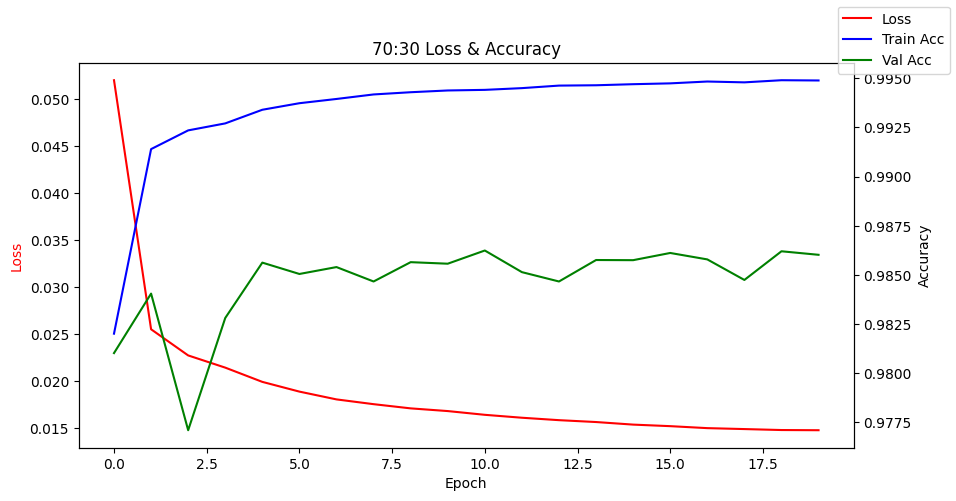

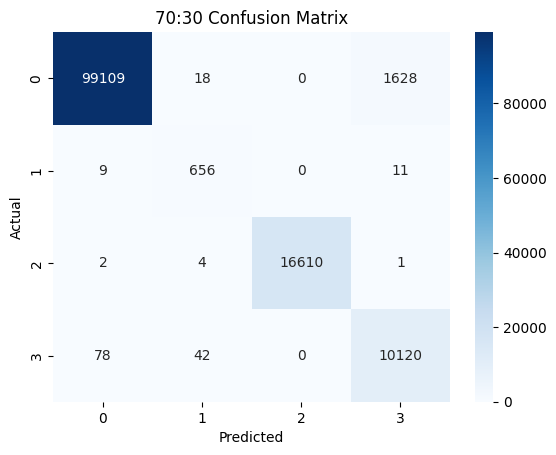

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.91      0.97      0.94       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.99      0.96    128288
weighted avg       0.99      0.99      0.99    128288



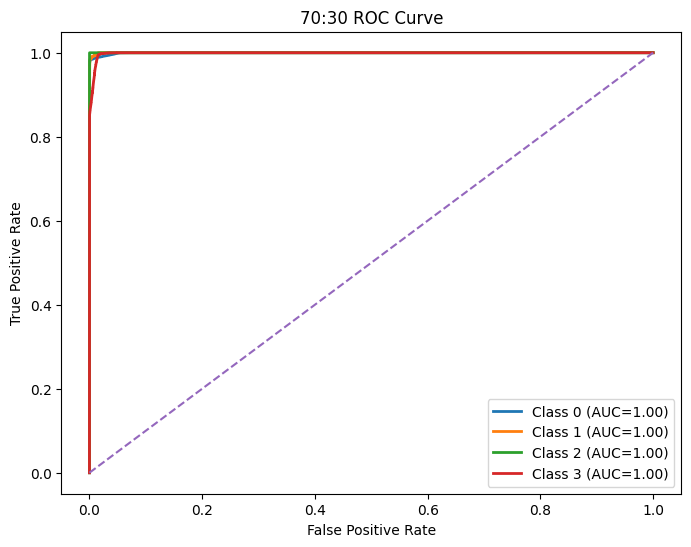

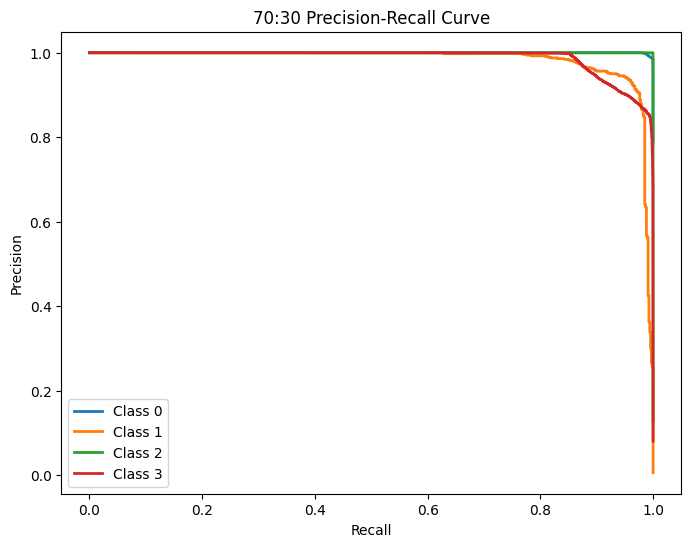


⏱️ Runtime: 1259.22 sec
💾 RAM used: 385.45 MB

========== 80:20 (SMOTE) ==========


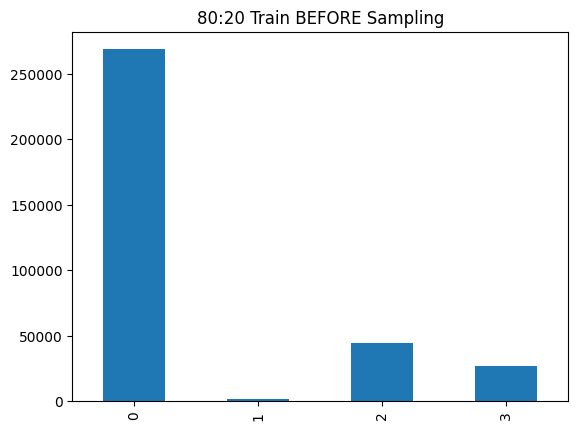

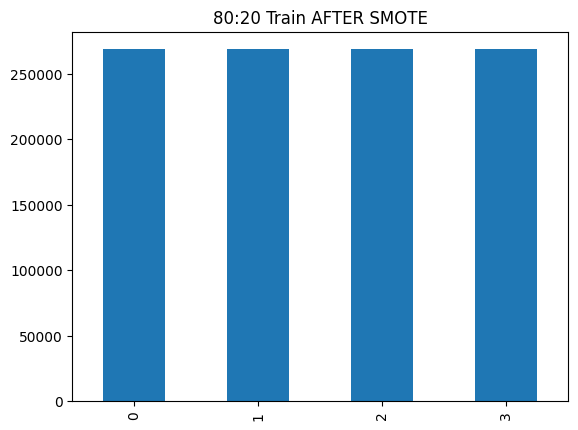

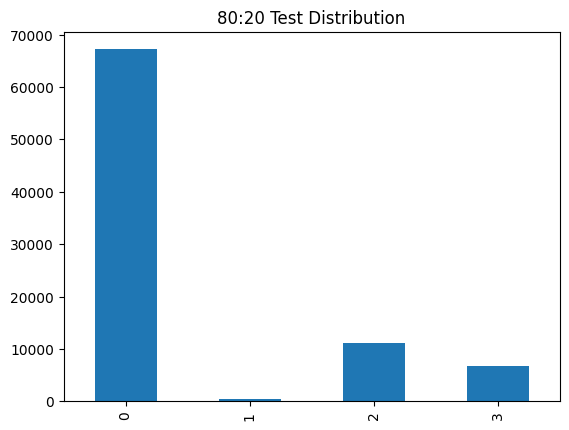

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.0481, TrainAcc=0.9833, TestAcc=0.9793, ROC-AUC=0.9993
Epoch 2: Loss=0.0244, TrainAcc=0.9919, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 3: Loss=0.0218, TrainAcc=0.9927, TestAcc=0.9826, ROC-AUC=0.9995
Epoch 4: Loss=0.0202, TrainAcc=0.9933, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 5: Loss=0.0190, TrainAcc=0.9937, TestAcc=0.9851, ROC-AUC=0.9996
Epoch 6: Loss=0.0185, TrainAcc=0.9938, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 7: Loss=0.0178, TrainAcc=0.9940, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 8: Loss=0.0174, TrainAcc=0.9941, TestAcc=0.9824, ROC-AUC=0.9995
Epoch 9: Loss=0.0171, TrainAcc=0.9942, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 10: Loss=0.0168, TrainAcc=0.9943, TestAcc=0.9856, ROC-AUC=0.9996
Epoch 11: Loss=0.0163, TrainAcc=0.9945, TestAcc=0.9862, ROC-AUC=0.9995
Epoch 12: Loss=0.0161, TrainAcc=0.9945, TestAcc=0.9846, ROC-AUC=0.9996
Epoch 13: Loss=0.0159, TrainAcc=0.9946, TestAcc=0.9862, ROC-AUC=0.9995
Epoch 14: Loss=0.0156, TrainAcc=0.9947, TestAcc=

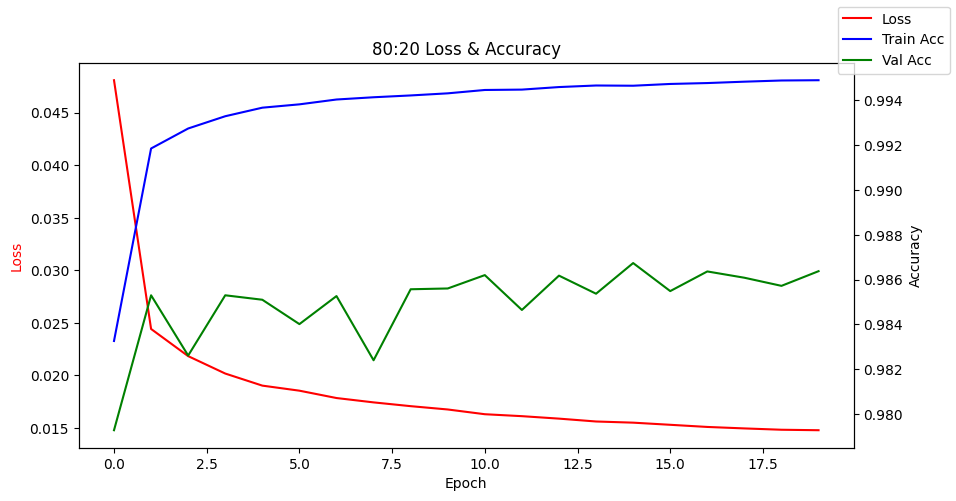

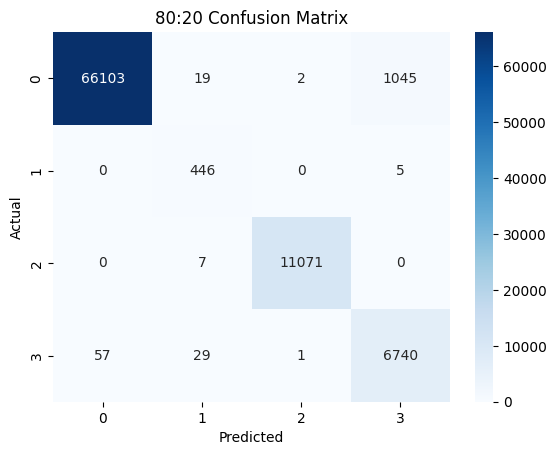

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.89      0.99      0.94       451
           2       1.00      1.00      1.00     11078
           3       0.87      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.99      0.99     85525



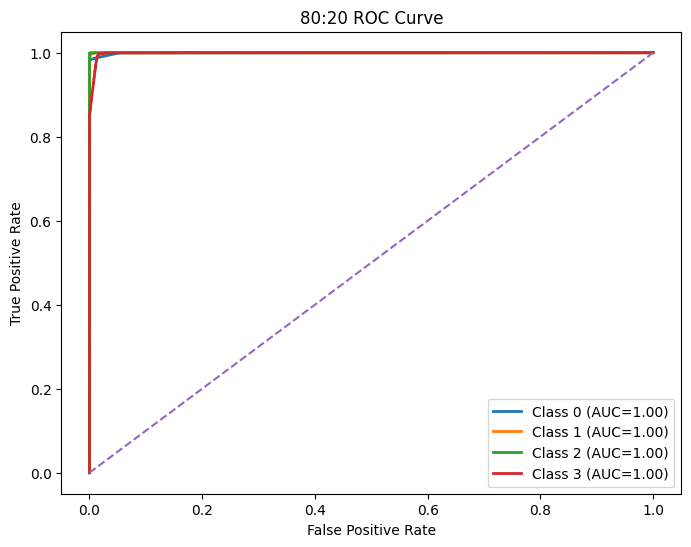

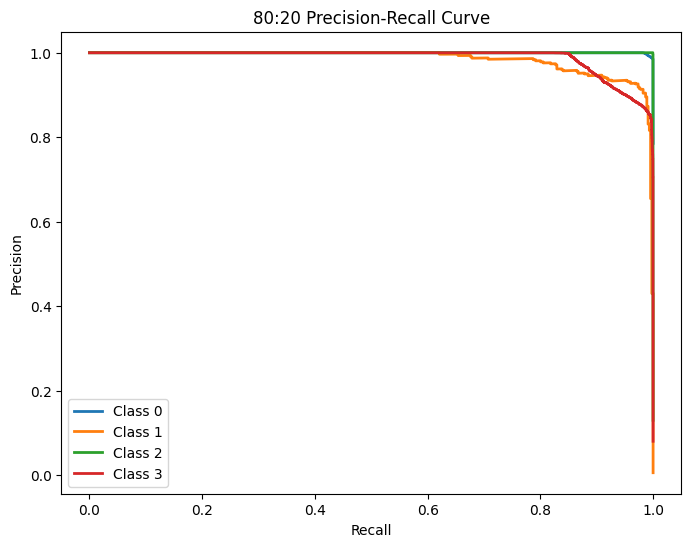


⏱️ Runtime: 1414.71 sec
💾 RAM used: 395.62 MB


In [15]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", test_size=0.4)
run_split_smote(df, "70:30", test_size=0.3)
run_split_smote(df, "80:20", test_size=0.2)

# ADASYN

In [16]:
def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} (ADASYN) ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # ADASYN (ONLY)
    # =============================
    from imblearn.over_sampling import ADASYN
    adasyn = ADASYN()

    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER ADASYN"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 (ADASYN) ==========


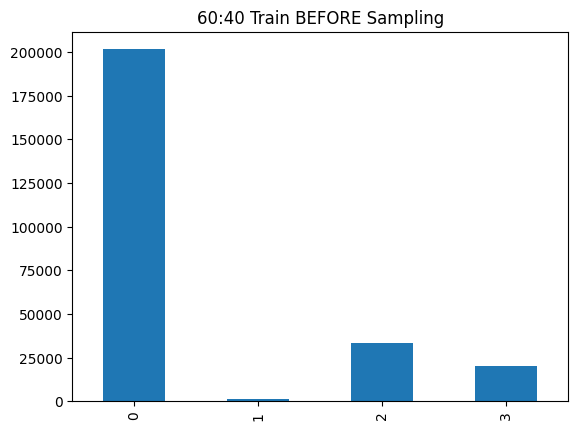

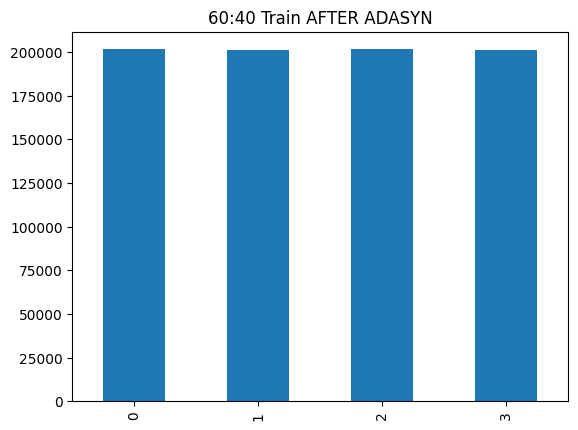

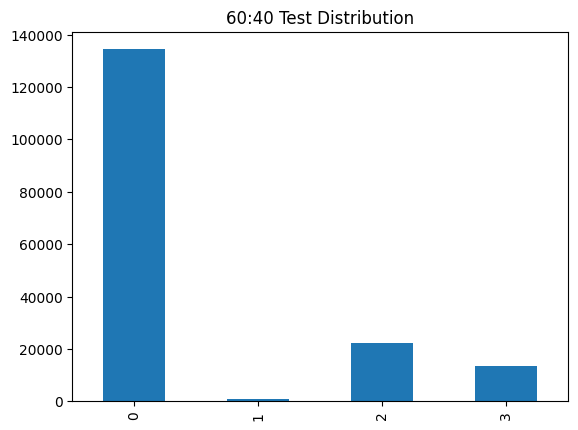

Train size: 805442
Test size : 171050
Epoch 1: Loss=0.0685, TrainAcc=0.9765, TestAcc=0.9790, ROC-AUC=0.9993
Epoch 2: Loss=0.0307, TrainAcc=0.9904, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 3: Loss=0.0274, TrainAcc=0.9914, TestAcc=0.9798, ROC-AUC=0.9994
Epoch 4: Loss=0.0250, TrainAcc=0.9922, TestAcc=0.9801, ROC-AUC=0.9994
Epoch 5: Loss=0.0236, TrainAcc=0.9926, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 6: Loss=0.0226, TrainAcc=0.9929, TestAcc=0.9849, ROC-AUC=0.9994
Epoch 7: Loss=0.0215, TrainAcc=0.9932, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 8: Loss=0.0209, TrainAcc=0.9934, TestAcc=0.9837, ROC-AUC=0.9995
Epoch 9: Loss=0.0203, TrainAcc=0.9936, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 10: Loss=0.0200, TrainAcc=0.9937, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 11: Loss=0.0194, TrainAcc=0.9938, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 12: Loss=0.0191, TrainAcc=0.9939, TestAcc=0.9828, ROC-AUC=0.9994
Epoch 13: Loss=0.0188, TrainAcc=0.9941, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 14: Loss=0.0185, TrainAcc=0.9942, TestAcc=

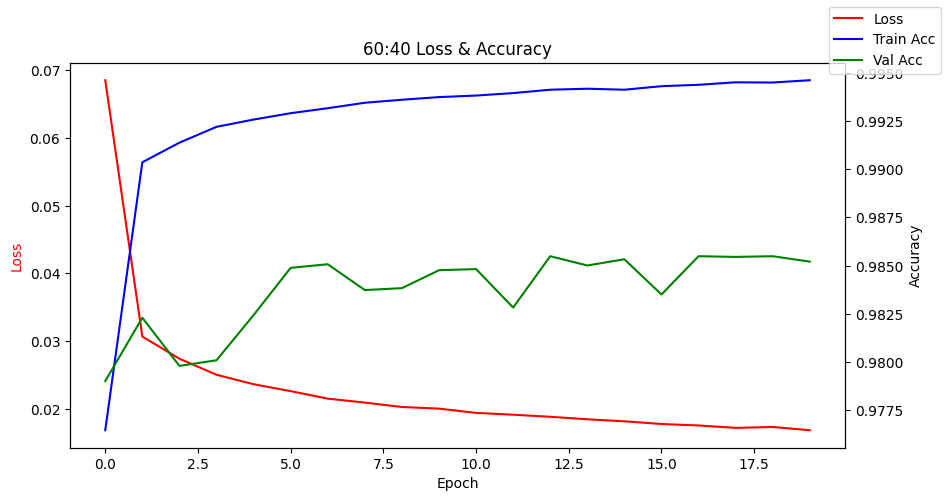

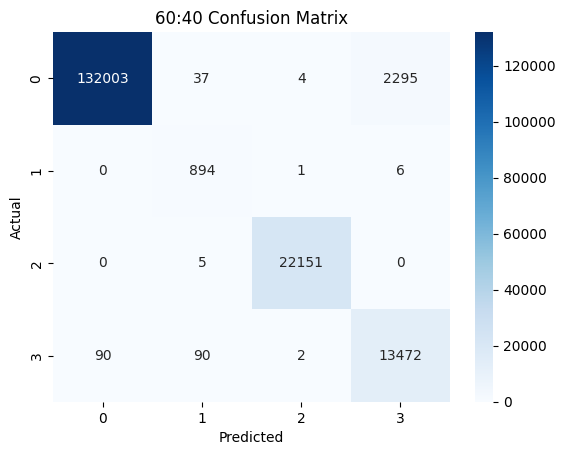

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.87      0.99      0.93       901
           2       1.00      1.00      1.00     22156
           3       0.85      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.93      0.99      0.96    171050
weighted avg       0.99      0.99      0.99    171050



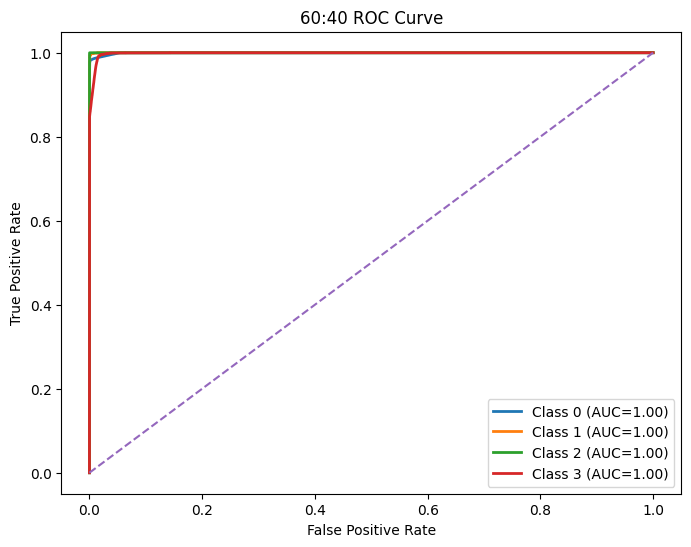

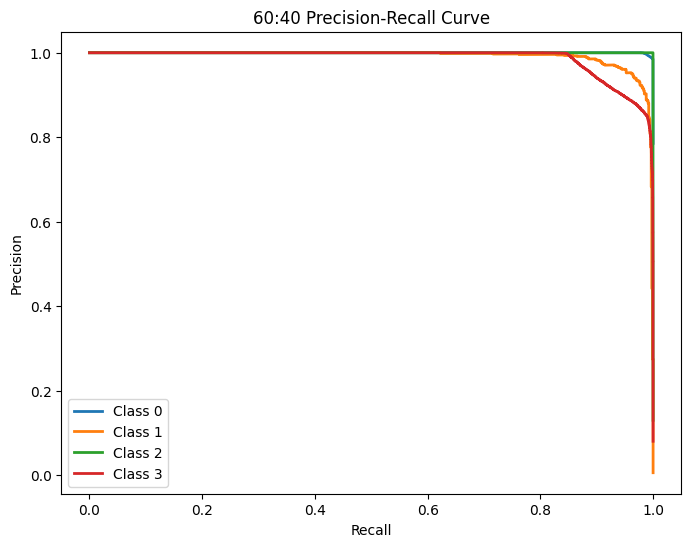


⏱️ Runtime: 1140.62 sec
💾 RAM used: 362.05 MB

========== 70:30 (ADASYN) ==========


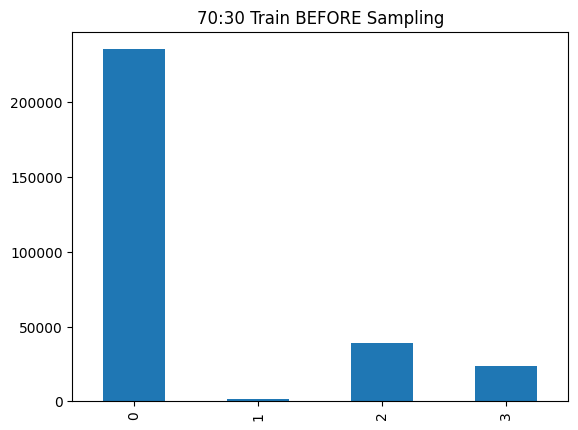

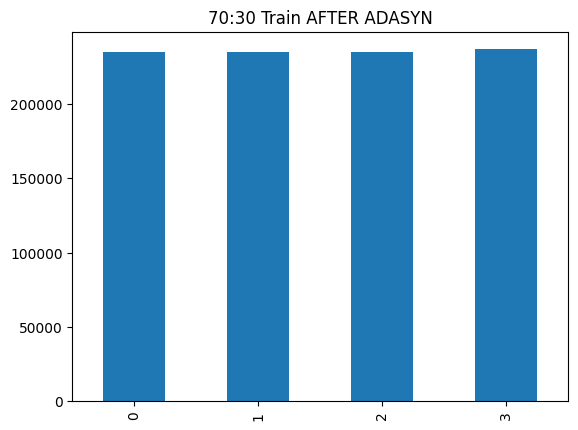

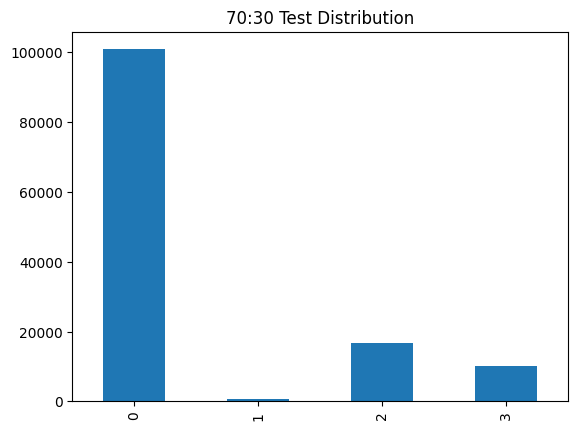

Train size: 942085
Test size : 128288
Epoch 1: Loss=0.0656, TrainAcc=0.9777, TestAcc=0.9790, ROC-AUC=0.9991
Epoch 2: Loss=0.0303, TrainAcc=0.9906, TestAcc=0.9799, ROC-AUC=0.9994
Epoch 3: Loss=0.0268, TrainAcc=0.9917, TestAcc=0.9829, ROC-AUC=0.9995
Epoch 4: Loss=0.0246, TrainAcc=0.9923, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 5: Loss=0.0232, TrainAcc=0.9928, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 6: Loss=0.0224, TrainAcc=0.9931, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 7: Loss=0.0218, TrainAcc=0.9933, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 8: Loss=0.0208, TrainAcc=0.9935, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 9: Loss=0.0202, TrainAcc=0.9937, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 10: Loss=0.0200, TrainAcc=0.9938, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 11: Loss=0.0192, TrainAcc=0.9940, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 12: Loss=0.0191, TrainAcc=0.9940, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 13: Loss=0.0187, TrainAcc=0.9942, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 14: Loss=0.0183, TrainAcc=0.9943, TestAcc=

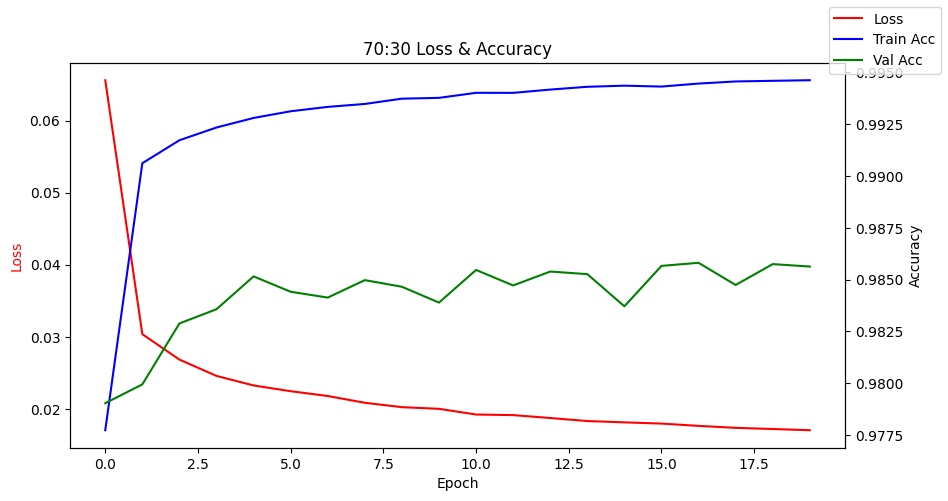

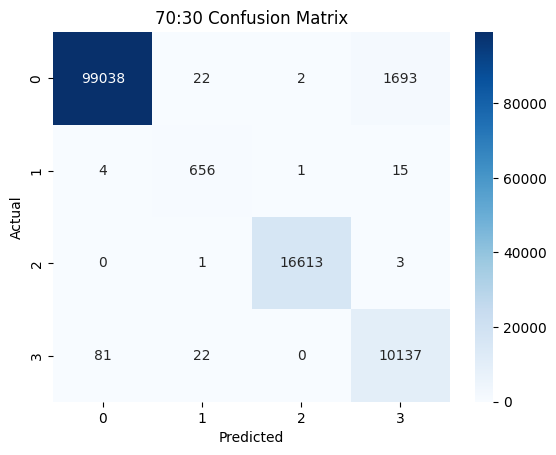

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.94      0.97      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



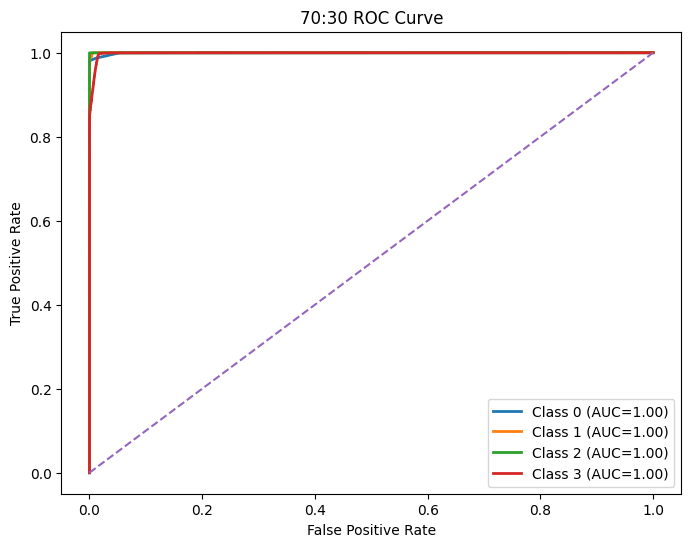

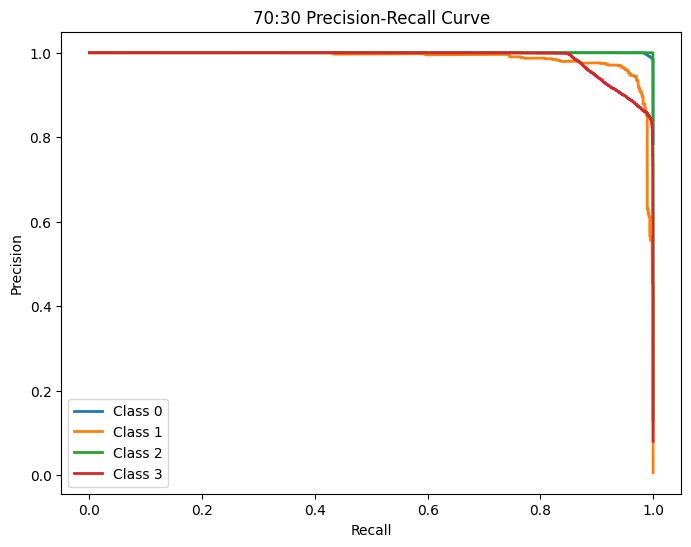


⏱️ Runtime: 1307.80 sec
💾 RAM used: 351.44 MB

========== 80:20 (ADASYN) ==========


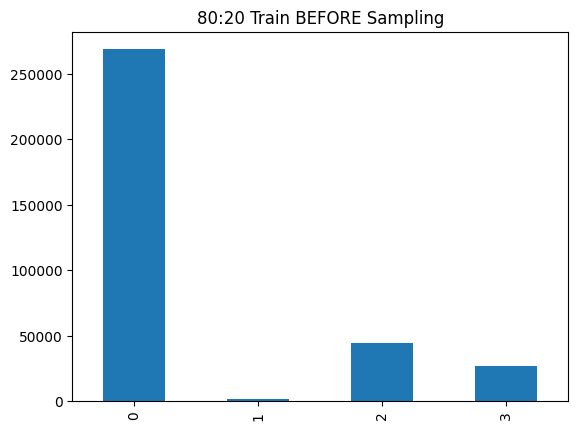

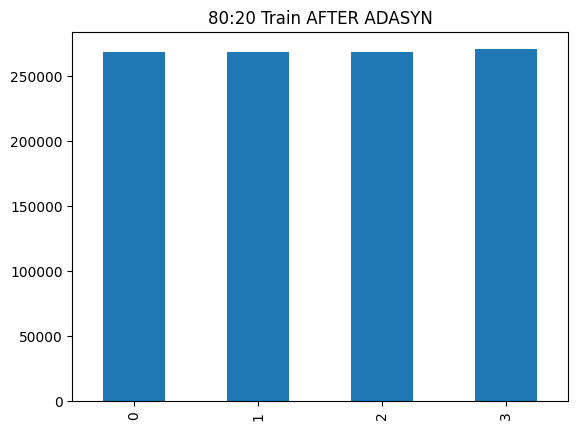

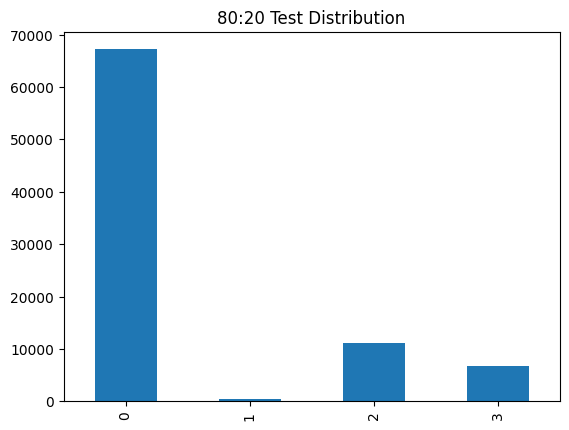

Train size: 1076489
Test size : 85525
Epoch 1: Loss=0.0617, TrainAcc=0.9790, TestAcc=0.9776, ROC-AUC=0.9994
Epoch 2: Loss=0.0299, TrainAcc=0.9908, TestAcc=0.9788, ROC-AUC=0.9994
Epoch 3: Loss=0.0262, TrainAcc=0.9919, TestAcc=0.9826, ROC-AUC=0.9995
Epoch 4: Loss=0.0242, TrainAcc=0.9926, TestAcc=0.9837, ROC-AUC=0.9995
Epoch 5: Loss=0.0228, TrainAcc=0.9930, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 6: Loss=0.0217, TrainAcc=0.9934, TestAcc=0.9856, ROC-AUC=0.9996
Epoch 7: Loss=0.0209, TrainAcc=0.9936, TestAcc=0.9853, ROC-AUC=0.9996
Epoch 8: Loss=0.0205, TrainAcc=0.9937, TestAcc=0.9843, ROC-AUC=0.9996
Epoch 9: Loss=0.0198, TrainAcc=0.9939, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 10: Loss=0.0195, TrainAcc=0.9939, TestAcc=0.9852, ROC-AUC=0.9996
Epoch 11: Loss=0.0190, TrainAcc=0.9941, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 12: Loss=0.0189, TrainAcc=0.9942, TestAcc=0.9855, ROC-AUC=0.9996
Epoch 13: Loss=0.0184, TrainAcc=0.9943, TestAcc=0.9858, ROC-AUC=0.9996
Epoch 14: Loss=0.0181, TrainAcc=0.9944, TestAcc=

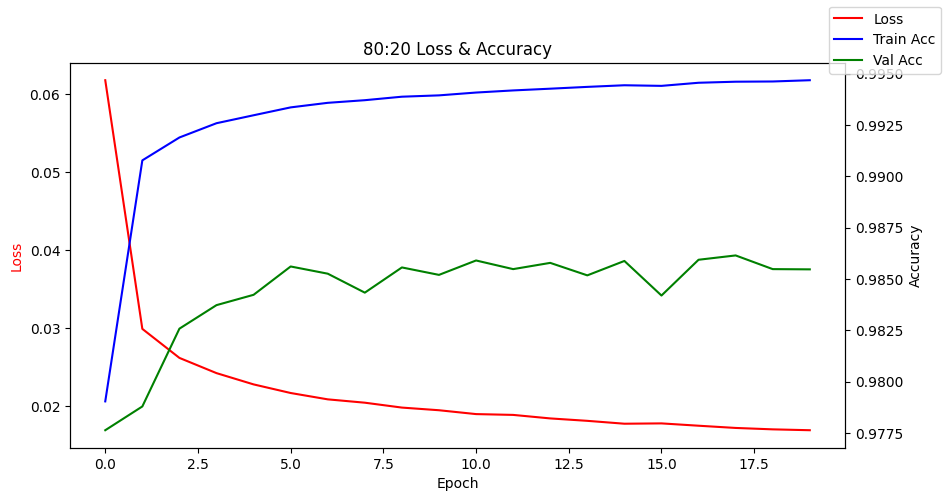

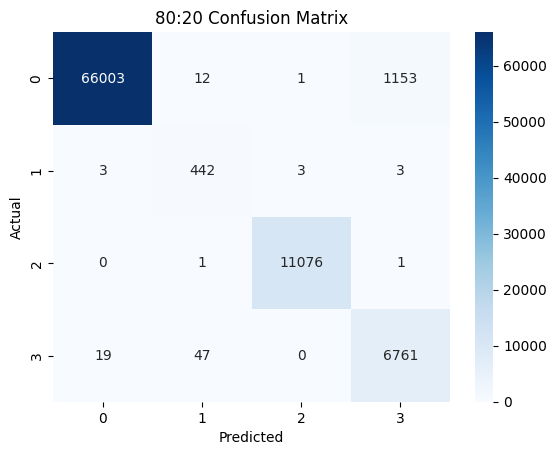

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.88      0.98      0.93       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.93      0.99      0.96     85525
weighted avg       0.99      0.99      0.99     85525



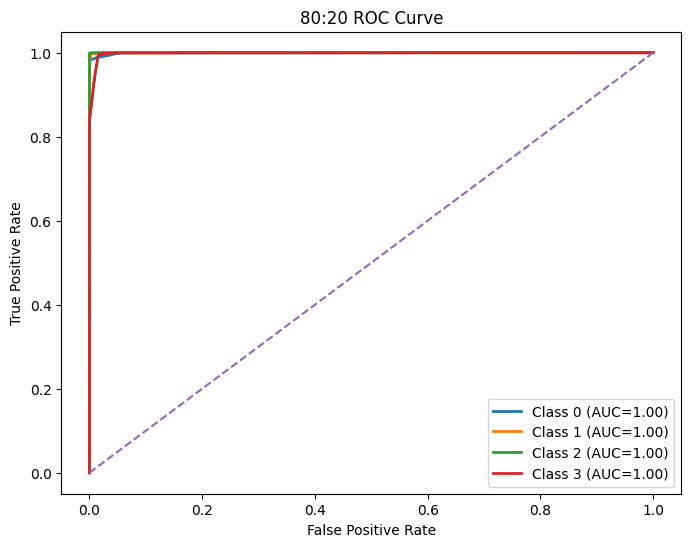

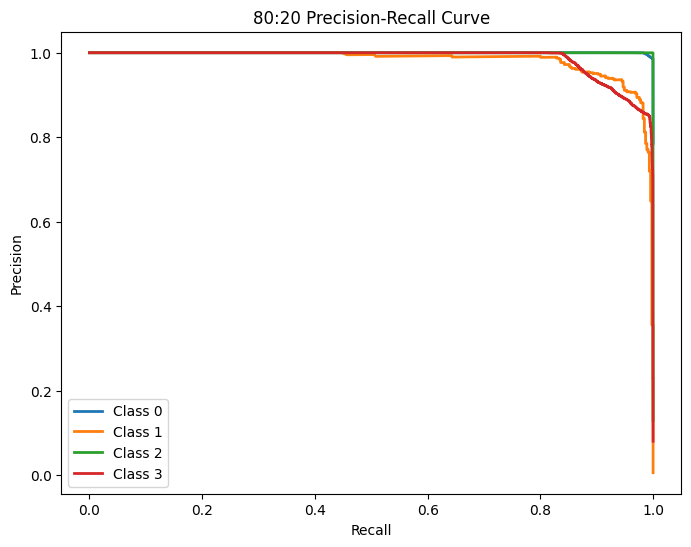


⏱️ Runtime: 1477.74 sec
💾 RAM used: 415.16 MB


In [17]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", test_size=0.4)
run_split_adasyn(df, "70:30", test_size=0.3)
run_split_adasyn(df, "80:20", test_size=0.2)

# ADASYN + TOmek_Links

In [10]:
def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} (ADASYN + Tomek Links) ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # ADASYN + TOMEK LINKS
    # =============================
    from imblearn.over_sampling import ADASYN
    from imblearn.under_sampling import TomekLinks

    # Step 1: ADASYN (oversampling)
    adasyn = ADASYN()
    X_res, y_res = adasyn.fit_resample(X_train, y_train)

    # Step 2: Tomek Links (cleaning)
    tomek = TomekLinks()
    X_train, y_train = tomek.fit_resample(X_res, y_res)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER ADASYN + Tomek"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 (ADASYN + Tomek Links) ==========


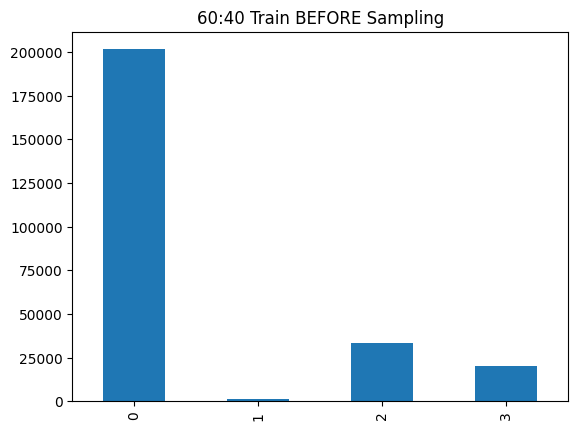

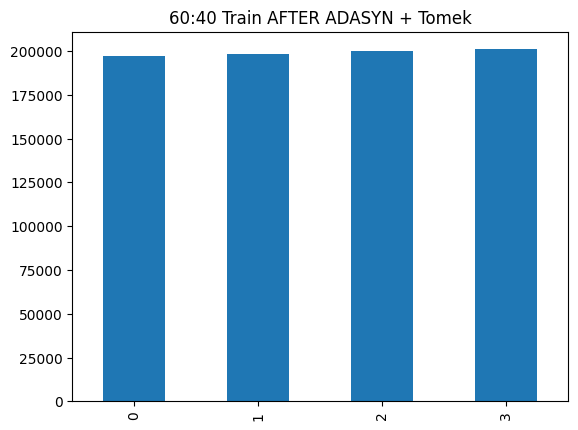

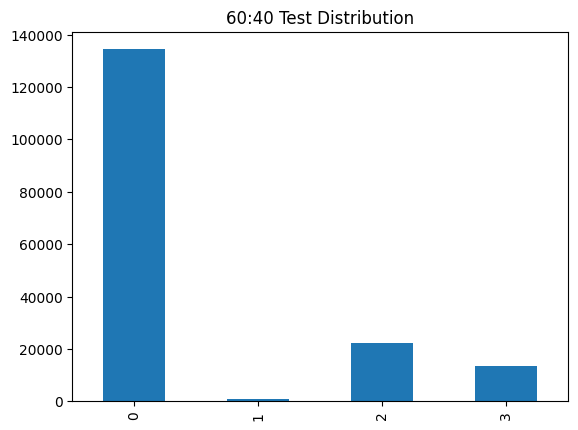

Train size: 796697
Test size : 171050
Epoch 1: Loss=0.0686, TrainAcc=0.9765, TestAcc=0.9807, ROC-AUC=0.9992
Epoch 2: Loss=0.0300, TrainAcc=0.9909, TestAcc=0.9772, ROC-AUC=0.9994
Epoch 3: Loss=0.0260, TrainAcc=0.9920, TestAcc=0.9786, ROC-AUC=0.9993
Epoch 4: Loss=0.0238, TrainAcc=0.9928, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 5: Loss=0.0224, TrainAcc=0.9931, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 6: Loss=0.0213, TrainAcc=0.9936, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 7: Loss=0.0202, TrainAcc=0.9938, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 8: Loss=0.0195, TrainAcc=0.9941, TestAcc=0.9837, ROC-AUC=0.9995
Epoch 9: Loss=0.0190, TrainAcc=0.9942, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 10: Loss=0.0184, TrainAcc=0.9943, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 11: Loss=0.0180, TrainAcc=0.9945, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 12: Loss=0.0177, TrainAcc=0.9946, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 13: Loss=0.0172, TrainAcc=0.9946, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 14: Loss=0.0170, TrainAcc=0.9947, TestAcc=

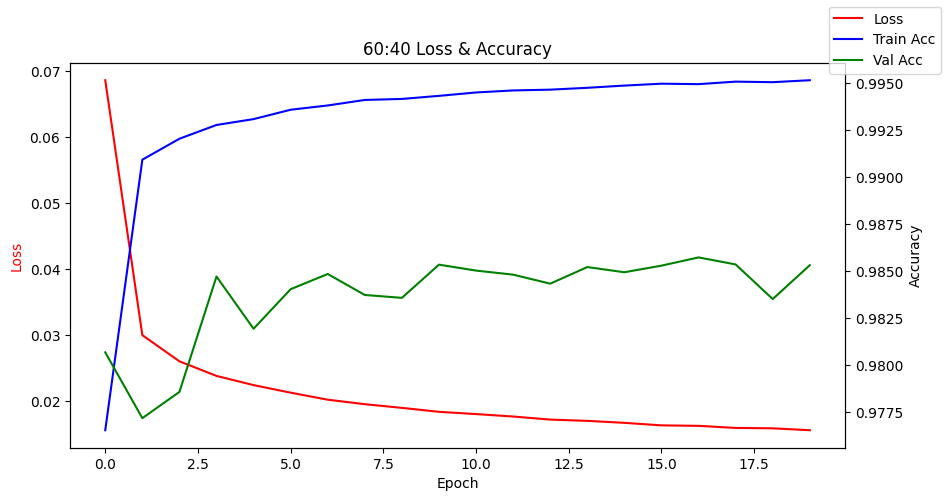

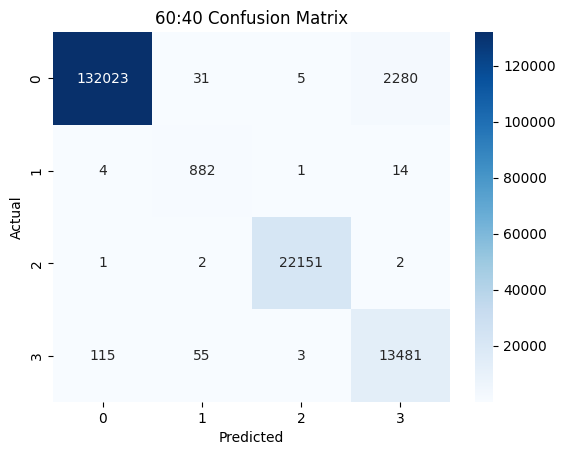

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.91      0.98      0.94       901
           2       1.00      1.00      1.00     22156
           3       0.85      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.99      0.99      0.99    171050



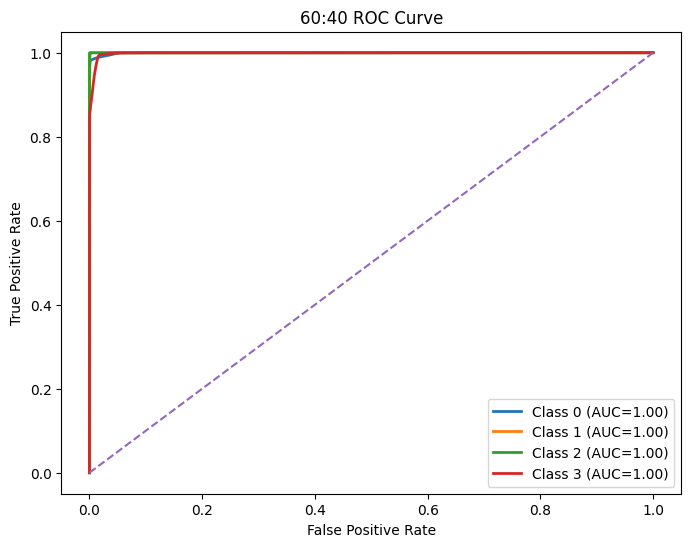

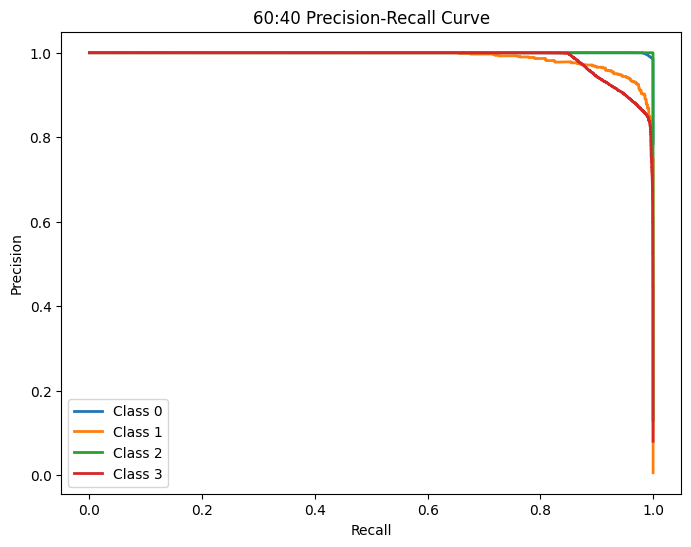


⏱️ Runtime: 2713.92 sec
💾 RAM used: 486.30 MB

========== 70:30 (ADASYN + Tomek Links) ==========


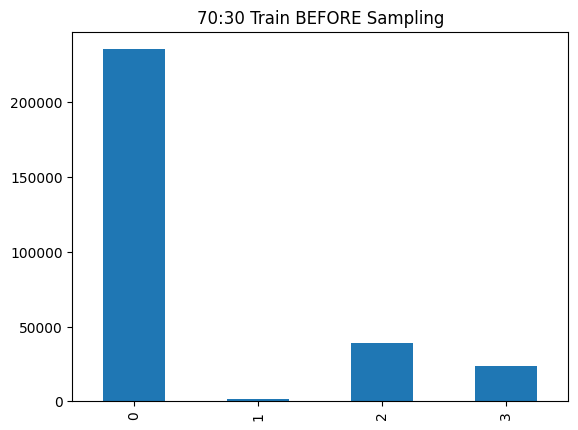

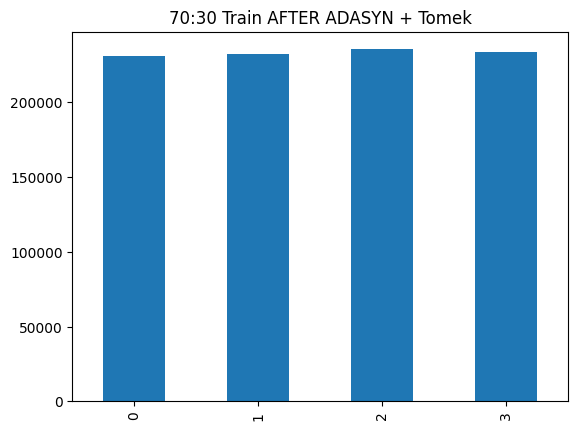

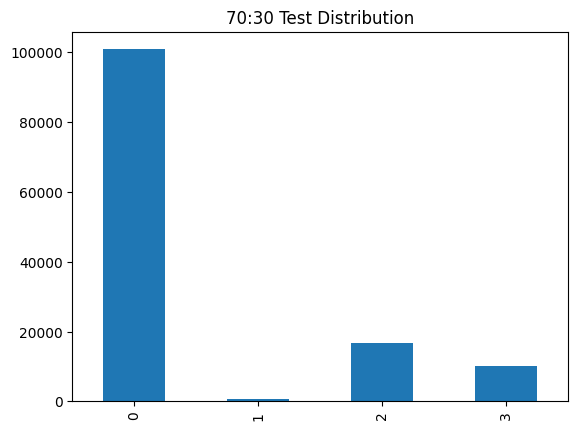

Train size: 931320
Test size : 128288
Epoch 1: Loss=0.0634, TrainAcc=0.9785, TestAcc=0.9815, ROC-AUC=0.9993
Epoch 2: Loss=0.0280, TrainAcc=0.9914, TestAcc=0.9840, ROC-AUC=0.9994
Epoch 3: Loss=0.0246, TrainAcc=0.9925, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 4: Loss=0.0228, TrainAcc=0.9931, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 5: Loss=0.0218, TrainAcc=0.9934, TestAcc=0.9848, ROC-AUC=0.9996
Epoch 6: Loss=0.0208, TrainAcc=0.9937, TestAcc=0.9823, ROC-AUC=0.9995
Epoch 7: Loss=0.0200, TrainAcc=0.9939, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 8: Loss=0.0193, TrainAcc=0.9942, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 9: Loss=0.0188, TrainAcc=0.9943, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 10: Loss=0.0183, TrainAcc=0.9944, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 11: Loss=0.0180, TrainAcc=0.9946, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 12: Loss=0.0176, TrainAcc=0.9946, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 13: Loss=0.0173, TrainAcc=0.9947, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 14: Loss=0.0171, TrainAcc=0.9948, TestAcc=

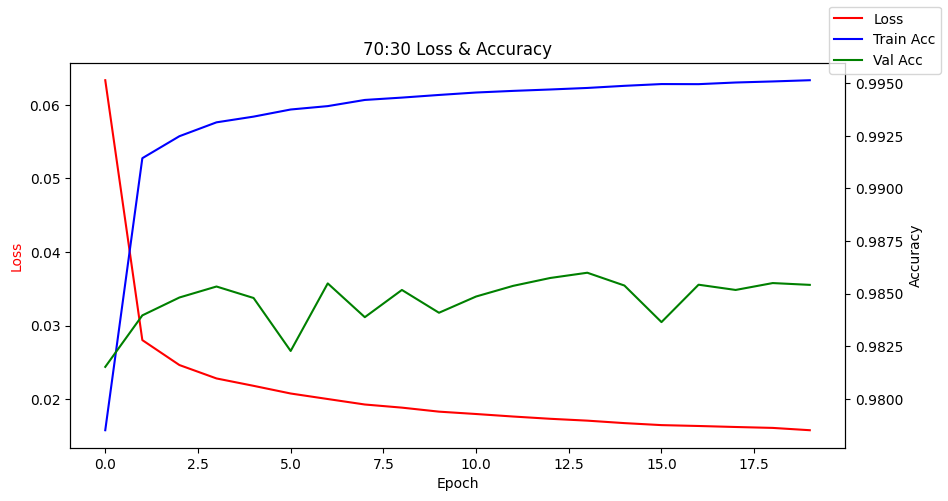

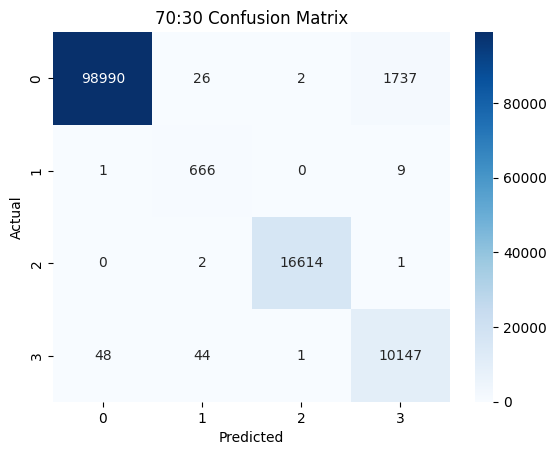

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.90      0.99      0.94       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.99      0.96    128288
weighted avg       0.99      0.99      0.99    128288



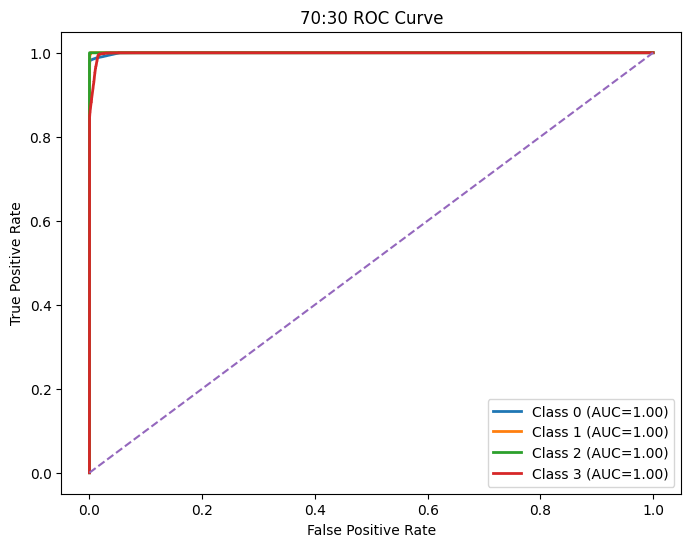

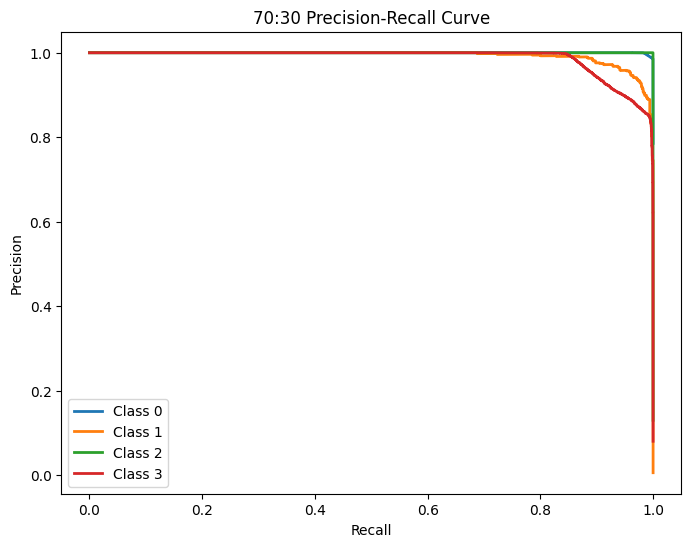


⏱️ Runtime: 3465.78 sec
💾 RAM used: 567.69 MB

========== 80:20 (ADASYN + Tomek Links) ==========


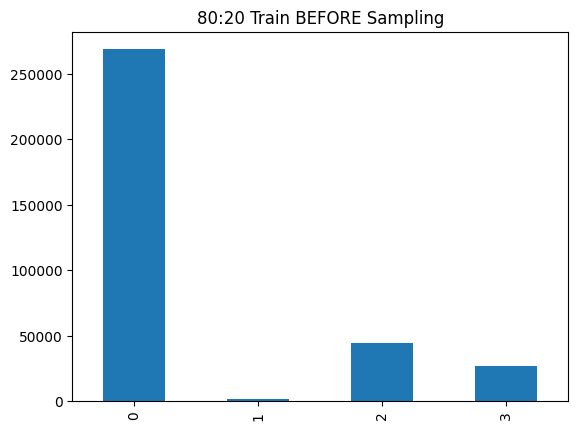

In [ ]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", test_size=0.4)
run_split_adasyn_tomek(df, "70:30", test_size=0.3)


========== 80:20 (ADASYN + Tomek Links) ==========


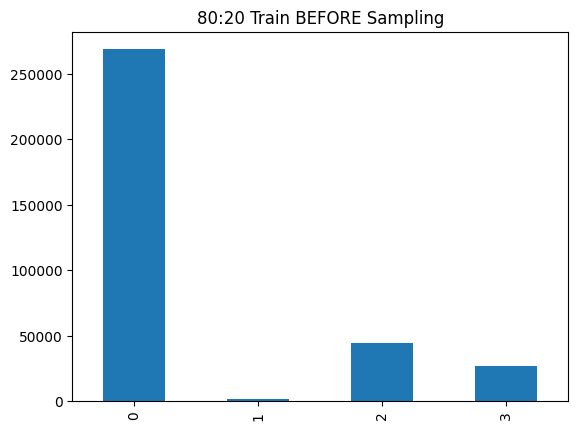

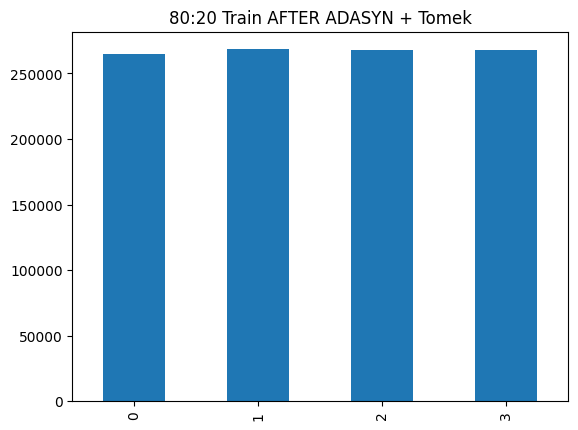

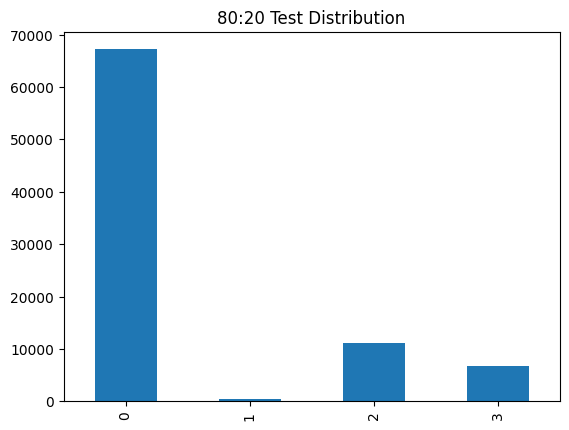

Train size: 1068232
Test size : 85525
Epoch 1: Loss=0.0631, TrainAcc=0.9789, TestAcc=0.9775, ROC-AUC=0.9992
Epoch 2: Loss=0.0311, TrainAcc=0.9905, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 3: Loss=0.0275, TrainAcc=0.9917, TestAcc=0.9834, ROC-AUC=0.9995
Epoch 4: Loss=0.0245, TrainAcc=0.9926, TestAcc=0.9842, ROC-AUC=0.9994
Epoch 5: Loss=0.0228, TrainAcc=0.9932, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 6: Loss=0.0218, TrainAcc=0.9935, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 7: Loss=0.0208, TrainAcc=0.9937, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 8: Loss=0.0200, TrainAcc=0.9940, TestAcc=0.9863, ROC-AUC=0.9995
Epoch 9: Loss=0.0196, TrainAcc=0.9940, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 10: Loss=0.0191, TrainAcc=0.9942, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 11: Loss=0.0187, TrainAcc=0.9943, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 12: Loss=0.0183, TrainAcc=0.9944, TestAcc=0.9860, ROC-AUC=0.9995
Epoch 13: Loss=0.0179, TrainAcc=0.9945, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 14: Loss=0.0178, TrainAcc=0.9946, TestAcc=

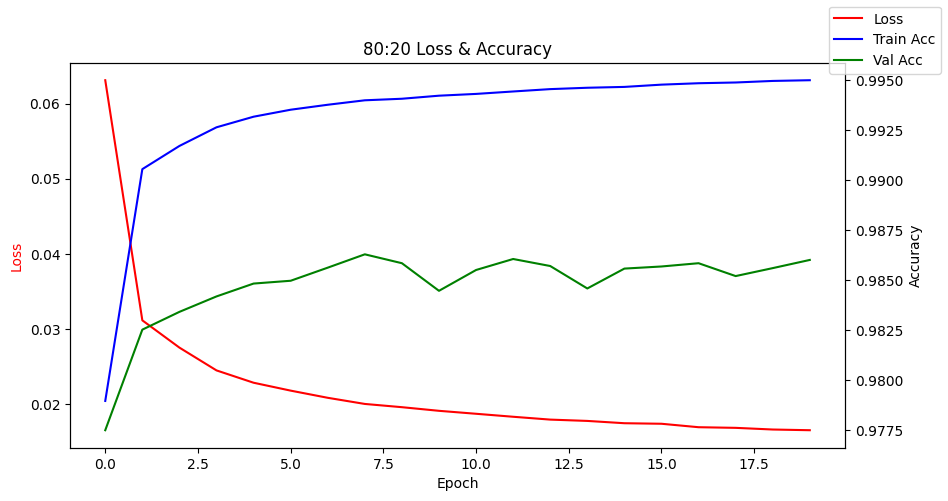

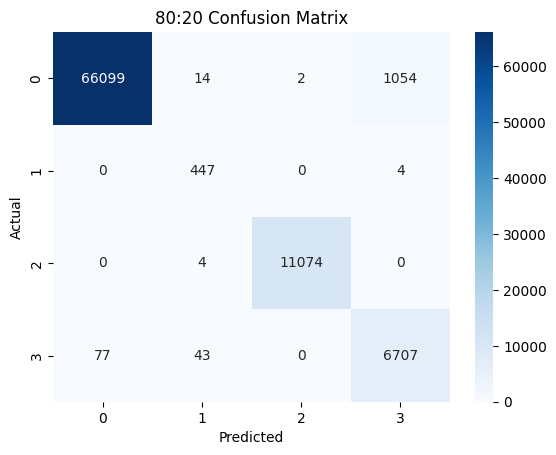

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.88      0.99      0.93       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.98      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.99      0.99     85525



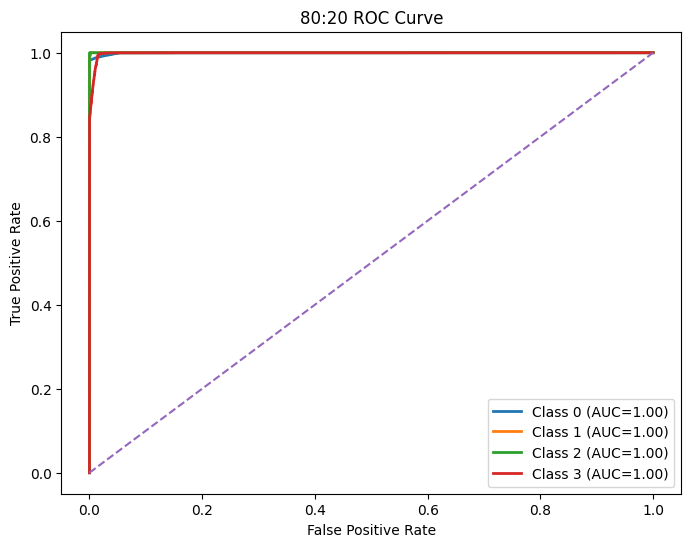

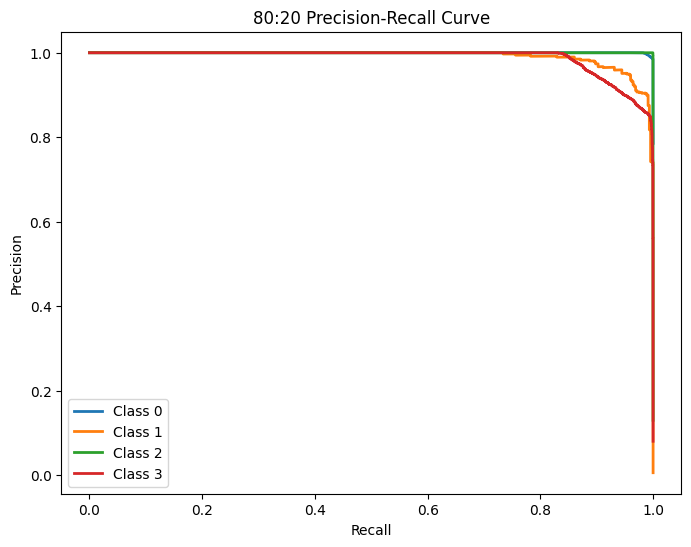


⏱️ Runtime: 4487.26 sec
💾 RAM used: 1327.67 MB


In [11]:
run_split_adasyn_tomek(df, "80:20", test_size=0.2)

In [12]:
!pip install numpy